### Dependencies

In [108]:
# !pip3 install langchain
# !pip3 install langchain-openai
# !pip3 install langchain-community unstructured
# !pip3 install langchain-chroma
# !pip3 install redis==7.3.0
# !pip3 install "unstructured[pdf]==0.21.5"
# !pip3 install htmltabletomd==1.0.0

In [4]:
# # install OCR dependencies for unstructured
# !sudo apt-get install tesseract-ocr
# !sudo apt-get install poppler-utils

### Data Preparation

In [64]:
from langchain_community.document_loaders import UnstructuredPDFLoader
import os


folder_path = "RAG Project Dataset"
all_docs = []  # Collect all loaded docs

for file_name in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file_name)

    # Process only PDF files
    if os.path.isfile(file_path) and file_name.lower().endswith(".pdf"):
        print(f"Processing: {file_name}")

        loader = UnstructuredPDFLoader(
            file_path=file_path,
            strategy='hi_res',
            extract_images_in_pdf=True,
            infer_table_structure=True,
            mode='elements',
            image_output_dir_path='./figures'
        )

        try:
            data = loader.load()
            all_docs.extend(data)  # store results
        except Exception as e:
            print(f"Error processing {file_name}: {e}")

print(f"Total documents loaded: {len(all_docs)}")

No languages specified, defaulting to English.


Processing: 2005.11401v4.pdf


No languages specified, defaulting to English.


Processing: 2005.14165v4.pdf


No languages specified, defaulting to English.


Processing: 1706.03762v7.pdf
Total documents loaded: 1444


In [65]:
tables_and_text_filtered_docs = [
    d for d in all_docs
    if d.metadata.get("page_number") in [2, 3, 5] and d.metadata['category'] in ['Table', 'NarrativeText', 'UncategorizedText']
]

len(tables_and_text_filtered_docs)

66

In [66]:
table = [d for d in tables_and_text_filtered_docs if d.metadata["category"] == "Table"]

In [67]:
table[0].metadata

{'source': 'RAG Project Dataset/2005.14165v4.pdf',
 'detection_class_prob': 0.837216317653656,
 'coordinates': {'points': ((np.float64(364.30645751953125),
    np.float64(474.5439453125)),
   (np.float64(364.30645751953125), np.float64(2878.76318359375)),
   (np.float64(2633.22314453125), np.float64(2878.76318359375)),
   (np.float64(2633.22314453125), np.float64(474.5439453125))),
  'system': 'PixelSpace',
  'layout_width': 2975,
  'layout_height': 3850},
 'last_modified': '2024-11-27T14:17:06',
 'text_as_html': '<table><tbody><tr><td></td><td colspan="3">Approach</td><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td>2.1</td><td>Modeland Architectures...</td><td></td><td></td><td></td><td>2...</td><td></td><td></td><td>ee</td><td></td><td></td></tr><tr><td>2.2</td><td>Training Dataset... 2...</td><td></td><td></td><td></td><td></td><td></td><td></td><td>ee</td><td></td><td></td></tr><tr><td>2.3.</td><td>Training Process .. 1...</td><td></td><td></td><td></td>

In [68]:
table[0].page_content

'Introduction Approach 2.1 Modeland Architectures... 2... ee 2.2 Training Dataset... 2... ee 2.3. Training Process .. 1... 2.4 Evaluation... 2... Results 3.1 Language Modeling, Cloze, and Completion Tasks ..................0 0000000. 3.2 Closed Book Question Answering ... 2... 2... ee 3.3. Translation 2... 3.4 Winograd-Style Tasks... 2. ee 3.5 Common Sense Reasoning .......... 0.0. ee ee 3.6 Reading Comprehension ............. 0.0 ee 3.7 SuperGLUE.... 2... 2. 3.8 NLT... . 3.9 Synthetic and Qualitative Tasks... 2... ee Measuring and Preventing Memorization Of Benchmarks Limitations Broader Impacts 6.1 Misuse of Language Models ...... 2... 0.0.0.2 ee ee 6.2 Fairness, Bias, and Representation... 2... 2... 6.3 Energy Usage... 2 2. Related Work Conclusion Details of Common Craw! Filtering Details of Model Training Details of Test Set Contamination Studies Total Compute Used to Train Language Models Human Quality Assessment of Synthetic News Articles Additional Samples from GPT-3 Details of 

In [71]:
# The splitting and chunking strategy
from langchain_text_splitters import RecursiveCharacterTextSplitter
tables_and_text_filtered_docs
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_docs = text_splitter.create_documents(
    [doc.page_content for doc in tables_and_text_filtered_docs]
)  

split_docs[0].page_content

'Figure 1: Overview of our approach. We combine a pre-trained retriever (Query Encoder + Document Index) with a pre-trained seq2seq model (Generator) and fine-tune end-to-end. For query x, we use Maximum Inner Product Search (MIPS) to find the top-K documents z;. For final prediction y, we treat z as a latent variable and marginalize over seq2seq predictions given different documents.'

In [81]:
len(split_docs)

70

In [72]:
! ls -l ./figures

total 1328
-rw-r--r--@ 1 varun.tyagi  staff  132839 Jun  2 23:44 figure-2-1.jpg
-rw-r--r--@ 1 varun.tyagi  staff  151687 Jun  2 23:48 figure-3-1.jpg
-rw-r--r--@ 1 varun.tyagi  staff   89163 Jun  2 23:48 figure-4-2.jpg
-rw-r--r--@ 1 varun.tyagi  staff  143540 Jun  2 23:47 figure-5-3.jpg


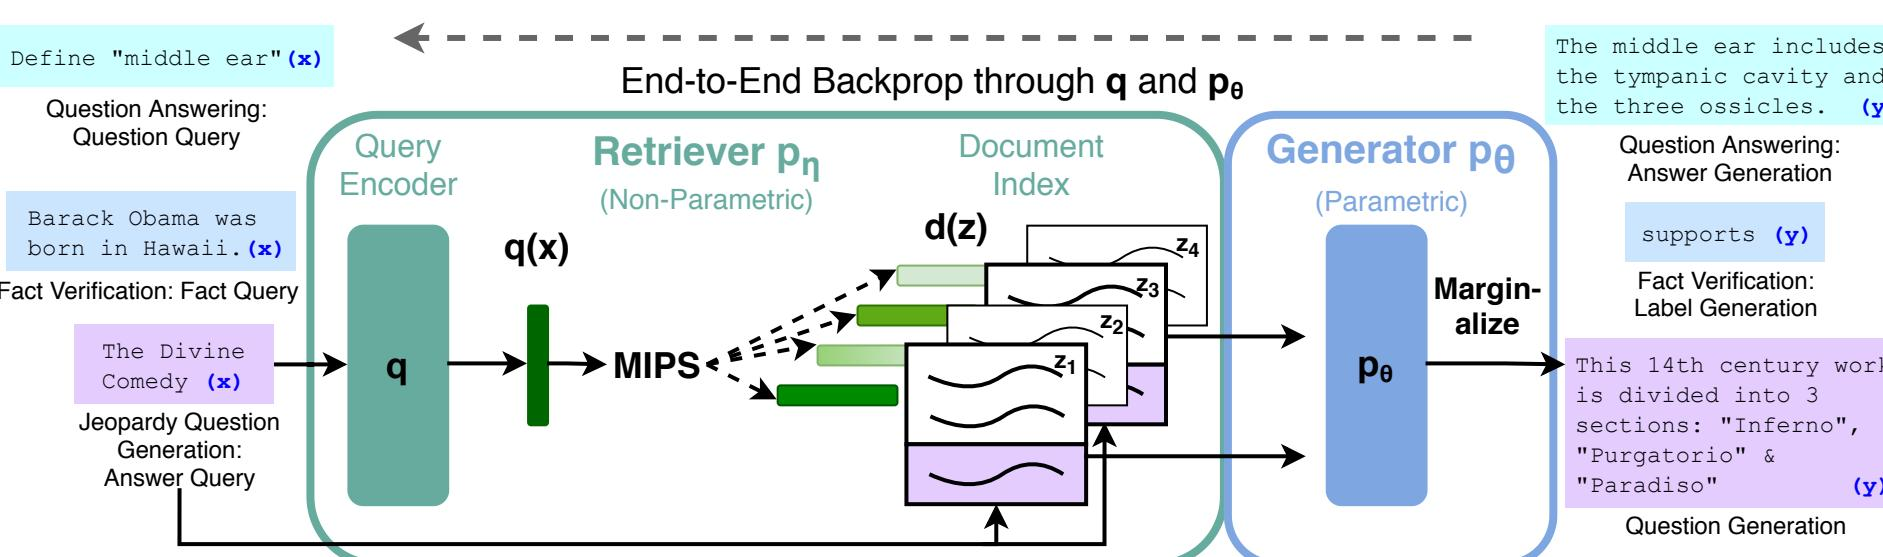

In [73]:
from IPython.display import Image

Image('./figures/figure-2-1.jpg')

### LLM Summarization for Text, Table and Images

In [74]:
from getpass import getpass
OPENAI_KEY = getpass('Enter Open AI API Key: ')

In [75]:
import os
os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [79]:
from langchain_openai import ChatOpenAI
chatgpt = ChatOpenAI(model_name='gpt-4o-mini', temperature=0)

In [82]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough

# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text particularly for semantic retrieval.
These summaries will be embedded and used to retrieve the raw text or table elements
Give a detailed summary of the table or text below that is well optimized for retrieval.
For any tables also add in a one line description of what the table is about besides the summary.
Do not add redundant words like Summary.
Just output the actual summary content.

Table or text chunk:
{element}
"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
summarize_chain = (
                    {"element": RunnablePassthrough()}
                      |
                    prompt
                      |
                    chatgpt
                      |
                    StrOutputParser() # extracts the response as text and returns it as a string
)

# Initialize empty summaries
text_summaries = []
table_summaries = []

table_text_docs = [doc.page_content for doc in split_docs[:10]]
table_text_summaries = summarize_chain.batch(table_text_docs, {"max_concurrency": 5})

len(table_text_summaries)

10

In [83]:
import base64
import os

from langchain_core.messages import HumanMessage


def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def image_summarize(img_base64, prompt):
    """Make image summary"""
    chat = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content


def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval.
                Remember these images could potentially contain graphs, charts or tables also.
                These summaries will be embedded and used to retrieve the raw image for question answering.
                Give a detailed summary of the image that is well optimized for retrieval.
                Do not add additional words like Summary, This image represents, etc.
             """

    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries


# Image summaries
IMG_PATH = './figures'
imgs_base64, image_summaries = generate_img_summaries(IMG_PATH)

### Markdown

In [84]:
from langchain_openai import OpenAIEmbeddings

# details here: https://openai.com/blog/new-embedding-models-and-api-updates
openai_embed_model = OpenAIEmbeddings(model='text-embedding-3-small')

### Embeddings and Vector DB

In [91]:
import uuid

from langchain_classic.retrievers import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_community.utilities.redis import get_client
from langchain_chroma import Chroma
from langchain_core.documents import Document


def create_multi_vector_retriever(
    docstore, vectorstore, table_text_summaries, table_text_docs, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """


    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=docstore,
        id_key=id_key,
    )

    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    # Add texts, tables, and images
    # Check that table_text_summaries is not empty before adding
    if table_text_summaries:
        add_documents(retriever, table_text_summaries, table_text_docs)
    # Check that image_summaries is not empty before adding
    if image_summaries:
        add_documents(retriever, image_summaries, images)

    return retriever


# The vectorstore to use to index the summaries and their embeddings
chroma_db = Chroma(
    collection_name="mm_rag",
    embedding_function=openai_embed_model,
    collection_metadata={"hnsw:space": "cosine"},
)

# Initialize the storage layer - to store raw images, text and tables
docstore = InMemoryStore()

# Create retriever
retriever_multi_vector = create_multi_vector_retriever(
    docstore,
    chroma_db,
    table_text_summaries,
    table_text_docs,
    image_summaries,
    imgs_base64,
)

In [92]:
retriever_multi_vector

MultiVectorRetriever(vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x15e0d1310>, docstore=<langchain_core.stores.InMemoryStore object at 0x15e4b02d0>, search_kwargs={})

### Retrieval

In [93]:
# Check retrieval
query = "What are attentions in transformer ?"
docs = retriever_multi_vector.invoke(query, limit=5)

# We get 3 docs
len(docs)

4

In [94]:
docs

['...',
 'by 6 that generates a current token based on a context of the previous 7 — 1 tokens y.;_1, the original input x and a retrieved passage z.',
 '‘Code to run experiments with RAG has been open-sourced as part of the HuggingFace Transform- ers Library [66] and can be found at https: //github. com/huggingface/transformers/blob/master/ examples/rag/. An interactive demo of RAG models can be found at https: //huggingface.co/rag/']

### Formating the Output

In [100]:
import re
import base64
from langchain_core.documents import Document


def looks_like_base64(sb):
    """Check if the string looks like base64"""
    if not isinstance(sb, str):
        return False

    return re.fullmatch(r"[A-Za-z0-9+/]+={0,2}", sb) is not None


def is_image_data(b64data):
    """Check if base64 corresponds to an image using magic bytes"""
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }

    try:
        decoded = base64.b64decode(b64data)
        header = decoded[:8]

        for sig in image_signatures:
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def split_image_text_types(docs):
    """
    Split documents into images (base64) and text
    """
    b64_images = []
    texts = []

    for doc in docs:
        # Extract text safely
        if isinstance(doc, Document):
            content = doc.page_content
        else:
            content = doc

        if not isinstance(content, str):
            continue  # skip invalid entries

        # Detect base64 image
        if looks_like_base64(content) and is_image_data(content):
            b64_images.append(content)
        else:
            texts.append(content)

    return {
        "images": b64_images,
        "texts": texts
    }


In [101]:
r = split_image_text_types(docs)
r

{'images': ['...'],
 'texts': ['by 6 that generates a current token based on a context of the previous 7 — 1 tokens y.;_1, the original input x and a retrieved passage z.',
  '‘Code to run experiments with RAG has been open-sourced as part of the HuggingFace Transform- ers Library [66] and can be found at https: //github. com/huggingface/transformers/blob/master/ examples/rag/. An interactive demo of RAG models can be found at https: //huggingface.co/rag/']}

### RAG Retrieval Engine

In [102]:
from operator import itemgetter
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.messages import HumanMessage

def multimodal_prompt_function(data_dict):
    """
    Create a multimodal prompt with both text and image context.

    This function formats the provided context from `data_dict`, which contains
    text, tables, and base64-encoded images. It joins the text (with table) portions
    and prepares the image(s) in a base64-encoded format to be included in a message.

    The formatted text and images (context) along with the user question are used to
    construct a prompt for GPT-4o-mini
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text and tables for analysis
    text_message = {
        "type": "text",
        "text": (
            f"""You are an analyst tasked with understanding detailed information and trends
                from text documents, data tables, and charts and graphs in images.
                You will be given context information below which will be a mix of text, tables,
                and images usually of charts or graphs.
                Use this information to provide answers related to the user question.
                Analyze all the context information including tables, text and images to generate the answer.
                Do not make up answers, use the provided context documents below
                and answer the question to the best of your ability.

                User question:
                {data_dict['question']}

                Context documents:
                {formatted_texts}

                Answer:
            """
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]


# Create RAG chain
multimodal_rag = (
        {
            "context": itemgetter('context'),
            "question": itemgetter('input'),
        }
            |
        RunnableLambda(multimodal_prompt_function)
            |
        chatgpt
            |
        StrOutputParser()
)

# Pass input query to retriever and get context document elements
retrieve_docs = (itemgetter('input')
                    |
                retriever_multi_vector
                    |
                RunnableLambda(split_image_text_types))

# Below, we chain `.assign` calls. This takes a dict and successively
# adds keys-- "context" and "answer"-- where the value for each key
# is determined by a Runnable (function or chain executing at runtime).
# This helps in also having the retrieved context along with the answer generated by GPT-4o
multimodal_rag_w_sources = (RunnablePassthrough.assign(context=retrieve_docs)
                                               .assign(answer=multimodal_rag)
)

In [103]:
# Run RAG chain
query = "What are attentions in transformer ?"
response = multimodal_rag_w_sources.invoke({'input': query})
response

{'input': 'What are attentions in transformer ?',
 'context': {'images': ['...'],
  'texts': ['by 6 that generates a current token based on a context of the previous 7 — 1 tokens y.;_1, the original input x and a retrieved passage z.',
   '‘Code to run experiments with RAG has been open-sourced as part of the HuggingFace Transform- ers Library [66] and can be found at https: //github. com/huggingface/transformers/blob/master/ examples/rag/. An interactive demo of RAG models can be found at https: //huggingface.co/rag/']},
 'answer': 'In the context of transformers, attention mechanisms are crucial for processing sequences of data, such as text. They allow the model to weigh the importance of different tokens in the input sequence when generating an output token. \n\n### Key Types of Attention in Transformers:\n\n1. **Scaled Dot-Product Attention**:\n   - This is the fundamental building block of the attention mechanism. It computes attention scores by taking the dot product of query (Q

### Display the Generated Output

In [105]:
from IPython.display import display
from PIL import Image
import base64
from io import BytesIO

def plt_img_base64(doc):
    """Display an image from a Document object or base64 string."""

    # Try metadata first (where Unstructured stores image data)
    img_b64 = None

    if hasattr(doc, 'metadata'):
        img_b64 = doc.metadata.get('image_base64')

    # Fall back to page_content if no metadata image
    if not img_b64:
        if hasattr(doc, 'page_content'):
            img_b64 = doc.page_content
        elif isinstance(doc, str):
            img_b64 = doc

    if not img_b64:
        raise ValueError("No image data found in document")

    # Clean up base64 string
    img_b64 = img_b64.strip()
    if img_b64.startswith("data:image"):
        img_b64 = img_b64.split(",", 1)[1]

    img_data = base64.b64decode(img_b64)
    img = Image.open(BytesIO(img_data))
    display(img)


In [106]:
def multimodal_rag_qa(query):
    response = multimodal_rag_w_sources.invoke({'input': query})
    print('=='*50)
    print('Answer:')
    display(Markdown(response['answer']))
    print('--'*50)
    print('Sources:')
    text_sources = response['context']['texts']
    img_sources = response['context']['images']
    for text in text_sources:
        display(Markdown(text))
        print()
    for img in img_sources:
        plt_img_base64(img)
        print()
    print('=='*50)

Answer:


In the context of transformers, attention mechanisms are crucial for processing sequences of data, such as text. The primary types of attention used in transformers are:

1. **Scaled Dot-Product Attention**: This mechanism computes attention scores by taking the dot product of query (Q) and key (K) vectors, scaling the result, applying a softmax function to obtain probabilities, and then using these probabilities to weight the value (V) vectors. This allows the model to focus on different parts of the input sequence based on the current context.

2. **Multi-Head Attention**: This extends the scaled dot-product attention by allowing the model to jointly attend to information from different representation subspaces at different positions. It does this by running multiple scaled dot-product attention operations in parallel (heads), concatenating their outputs, and then applying a linear transformation. This enables the model to capture various relationships and dependencies in the data more effectively.

These attention mechanisms allow transformers to weigh the importance of different tokens in a sequence, enabling better context understanding and generation of outputs based on previous tokens.

----------------------------------------------------------------------------------------------------
Sources:


by 6 that generates a current token based on a context of the previous 7 — 1 tokens y.;_1, the original input x and a retrieved passage z.

‘Code to run experiments with RAG has been open-sourced as part of the HuggingFace Transform- ers Library [66] and can be found at https: //github. com/huggingface/transformers/blob/master/ examples/rag/. An interactive demo of RAG models can be found at https: //huggingface.co/rag/

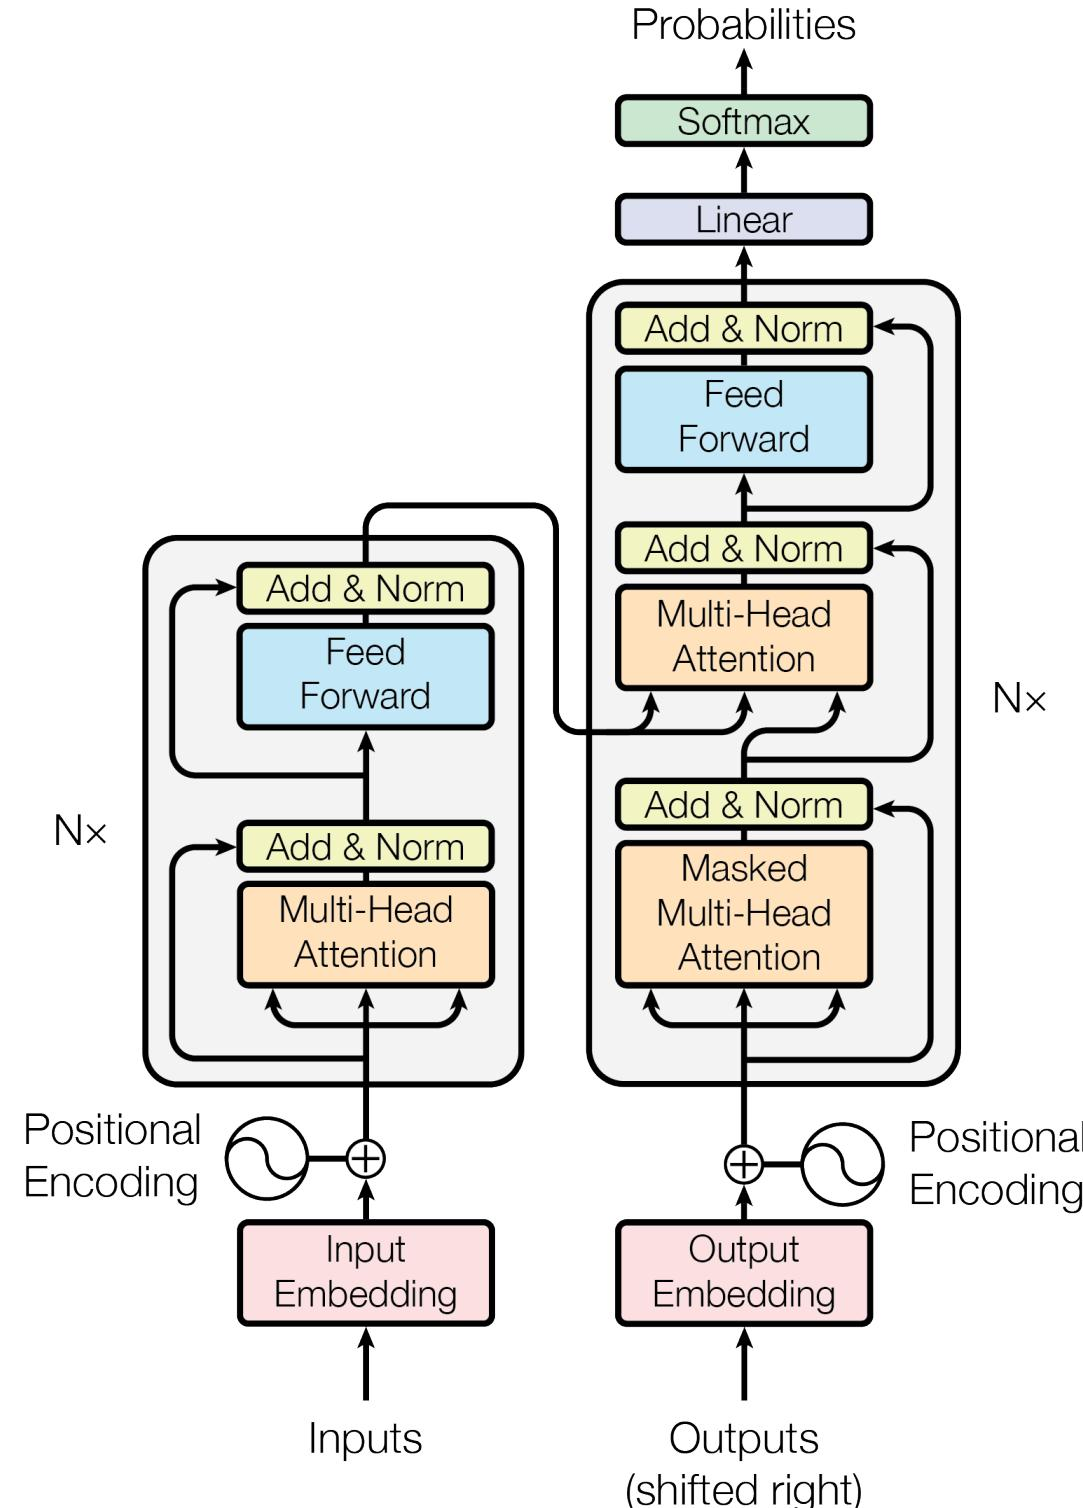

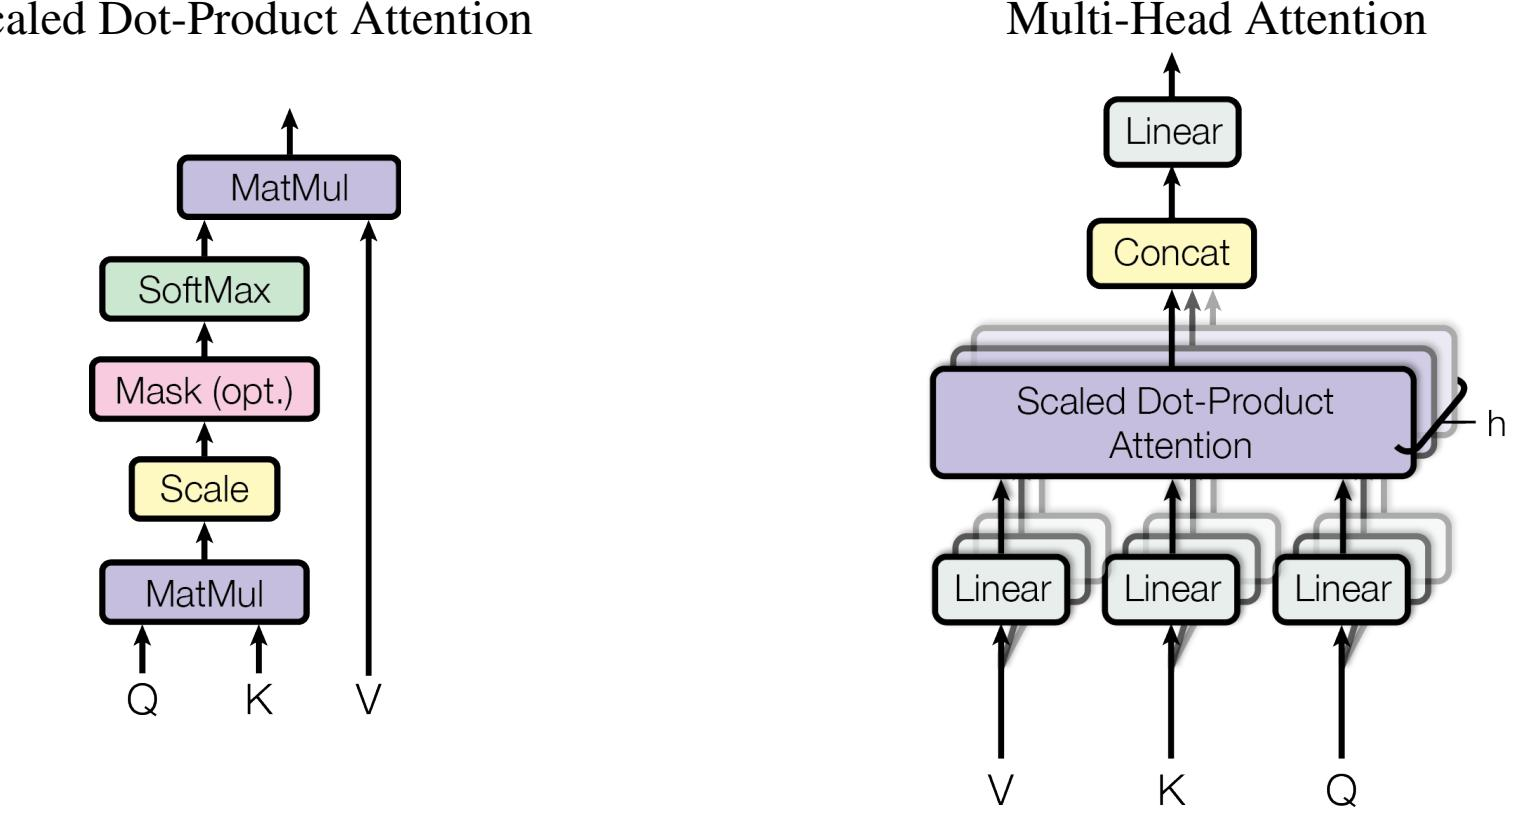

In [107]:
# Run RAG chain
query = "What are attentions in transformer ?"
response = multimodal_rag_qa(query)